# 自动驾驶：汽车检测（Autonomous Driving — Car Detection）

欢迎学习第三周的目标检测作业！本文件按照 `Autonomous_driving_application_Car_detection.ipynb` 的目录组织，结合 `Autonomous_driving_application_Car_detection_v3a.ipynb` 的相同练习，翻译说明并提供 PyTorch 实现。

完成后，你应能处理边界框、计算 IoU、实现分数过滤和非极大值抑制，并把课程 YOLOv2 的输出转换成可显示的检测框。本作业使用预训练模型推理，不包含从零训练 YOLO 的完整过程。

保留四个练习：`yolo_filter_boxes` → `iou` → `yolo_non_max_suppression` → `yolo_eval`，随后加载模型、解码输出、预测图片。TensorFlow Session 改为 PyTorch 即时执行；随机数测试改为可手算的样例，不复现跨框架固定随机输出。

目录：工具 → 1 问题描述 → 2 YOLO（2.1 模型细节，2.2 分数筛选，2.3 IoU，2.4 NMS，2.5 综合筛选）→ 3 预训练推理 → 4 总结 → 5 参考资料。

## 工具（Packages）

使用安装了 torch、numpy、Pillow、IPython 的内核。绘图完全使用 PIL，不导入 Matplotlib。重启内核后从头执行。

统一约定：神经网络输入为 NCHW；解码后的框使用原作业的 `(ymin,xmin,ymax,xmax)`；IoU 独立练习使用原题的 `(x1,y1,x2,y2)`，会在函数名旁标明。不要混淆框中心与角点。

In [1]:
import os
os.environ.setdefault("MKL_THREADING_LAYER", "SEQUENTIAL")
from pathlib import Path
from io import BytesIO
import time
import torch
from torch import nn
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Image as PNGImage

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def find_assignment():
    name = "Car detection for Autonomous Driving"
    for base in (Path.cwd(), *Path.cwd().parents):
        for p in (base, base/name, base/"C4 - Convolutional Neural Networks/Week 3"/name):
            if (p/"Autonomous_driving_application_Car_detection.ipynb").is_file():
                return p
    raise FileNotFoundError("请从项目目录内启动 Jupyter。")
ASSIGNMENT_DIR = find_assignment()
print("设备:", device, "作业目录:", ASSIGNMENT_DIR, flush=True)

def show_image(image):
    # PIL 编码静态 PNG，避开 Matplotlib 渲染后端。
    with BytesIO() as stream:
        image.save(stream, format="PNG")
        display(PNGImage(data=stream.getvalue()))

设备: cuda 作业目录: D:\ACMpractice\pytorch\learn_pytorch_WuEnDa\C4 - Convolutional Neural Networks\Week 3\Car detection for Autonomous Driving


## 1 - 问题描述（Problem Statement）

假设你在开发自动驾驶汽车。车载相机拍摄道路图片，训练数据需为目标标注类别与边界框；训练好的模型再对新图片自动预测。

![原作业：边界框标注](nb_images/box_label.png)

类别可以使用整数，也可以用 one-hot。本作业虽然名为汽车检测，使用的 YOLOv2 预训练模型实际上支持 COCO 的 80 类。

当前目录有道路样例图片，但 `model_data` 缺少完整权重：`saved_model.pb` 和 `variables.index` 不包含所有数值参数，不能单独恢复模型。下面的练习与绘图自检可离线运行；真实推理需要补齐兼容权重，不能把随机模型画出的框当检测结果。

## 2 - YOLO

YOLO 是 You Only Look Once：一次网络前向计算产生候选预测，再经过分数筛选与 NMS，输出类别、分数和边界框。

### 2.1 - 模型细节（Model Details）

原版输入 `(N,608,608,3)`，PyTorch 输入 `(N,3,608,608)`。课程网络产生 `19×19` 网格，每个网格 5 个 Anchor，每个 Anchor 有 $5+80=85$ 个数。

![原作业：YOLO 架构](nb_images/architecture.png)

$$19\times19\times5\times85=19\times19\times425.$$

每个位置对应存在性、四个框参数和 80 个类别。原始网络编码通常排列为 `(tx,ty,tw,th,to,class_logits...)`，需要解码，不能直接当成归一化坐标和概率。

![原作业：合并输出维度](nb_images/flatten.png)

每个物体按中心位置分配到网格，Anchor 提供宽高模板。总候选框数为 $19\times19\times5=1805$，不代表图中真的有 1805 个物体。

类别分数为：$score_k=p_c\times P(class=k\mid object)$。例如 $0.6\times0.73=0.438$。它与 IoU 不同：一个描述预测分数，一个衡量框重叠。

![原作业：类别分数](nb_images/probability_extraction.png)
![原作业：候选框](nb_images/anchor_map.png)

### 2.2 - 按类别分数筛选（Filtering with a Threshold on Class Scores）

解码后：`box_confidence` 为 `(H,W,A,1)`，`box_class_probs` 为 `(H,W,A,C)`，角点 `boxes` 为 `(H,W,A,4)`。本节仅处理一张图；批次中的图片必须分别处理，避免不同图片的框互相 NMS。

### 练习 1 - yolo_filter_boxes

先逐元素乘出各类分数，再取每个框最高分的类别，最后用布尔掩码保留分数不低于阈值的框。返回的候选框数量随图片变化。

In [2]:
def yolo_filter_boxes(boxes, box_confidence, box_class_probs, threshold=0.6):
    box_scores = box_confidence * box_class_probs
    box_class_scores, box_classes = box_scores.max(dim=-1)
    filtering_mask = box_class_scores >= threshold
    return (box_class_scores[filtering_mask], boxes[filtering_mask],
            box_classes[filtering_mask])

# 两个候选框、两个类别：最大分数分别为 0.72 和 0.35。
boxes = torch.tensor([[[[0.,0.,1.,1.], [0.,0.,0.5,0.5]]]])
confidence = torch.tensor([[[[0.9], [0.5]]]])
probs = torch.tensor([[[[0.8,0.2], [0.3,0.7]]]])
scores, kept_boxes, classes = yolo_filter_boxes(boxes, confidence, probs)
torch.testing.assert_close(scores, torch.tensor([0.72]))
assert kept_boxes.shape == (1,4) and classes.tolist() == [0]
assert yolo_filter_boxes(boxes,confidence,probs,0.99)[1].shape == (0,4)
print("练习 1 通过：保留分数 0.72 的第一个框；空结果也能处理。")

练习 1 通过：保留分数 0.72 的第一个框；空结果也能处理。


### 2.3 - 非极大值抑制与 IoU

筛选后，同一辆车仍可能有多个高分框。NMS 用 IoU 判断候选框是否高度重叠。

![原作业：重复汽车框](nb_images/non-max-suppression.png)
![原作业：交并比](nb_images/iou.png)

$$IoU=\frac{交集面积}{框1面积+框2面积-交集面积}.$$

### 练习 2 - iou

这里沿用原练习 `(x1,y1,x2,y2)` 的输入形式。坐标原点在左上角，x 向右、y 向下；宽高使用连续坐标差，不加 1。不相交或只接触边缘时交集为 0。

In [4]:
def iou(box1, box2):
    # 接收两个 Python 序列，格式均为 xyxy。
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    intersection = max(0, x2-x1) * max(0, y2-y1)
    area1 = max(0,box1[2]-box1[0]) * max(0,box1[3]-box1[1])
    area2 = max(0,box2[2]-box2[0]) * max(0,box2[3]-box2[1])
    union = area1 + area2 - intersection
    return intersection / union if union > 0 else 0.0

assert abs(iou((2,1,4,3),(1,2,3,4)) - 1/7) < 1e-7
assert iou((0,0,1,1),(2,2,3,3)) == 0
assert iou((0,0,1,1),(1,1,2,2)) == 0
assert iou((0,0,1,1),(1,0,2,1)) == 0
assert iou((0,0,1,1),(0,0,1,1)) == 1
print("练习 2 通过：相交 IoU=1/7，不相交、顶点/边接触为 0。")

练习 2 通过：相交 IoU=1/7，不相交、顶点/边接触为 0。


### 2.4 - YOLO 非极大值抑制（YOLO Non-max Suppression）

反复取最高分框，保留它，并删除与它 IoU 超过阈值的低分框。NMS 并不是整张图只保留一个框。

### 练习 3 - yolo_non_max_suppression

原作业对所有框调用一次 TensorFlow NMS。本版默认保留这个类别无关行为，便于对照；额外提供 `class_aware=True`，仅抑制同类别的重叠框。课程一般原理常按类别分别处理，两者不要混淆。

下面用纯 PyTorch 写出贪心循环，避免依赖额外的 torchvision NMS 编译算子。采用 IoU > 阈值时抑制，等于阈值保留；相同分数的框按原顺序处理。`max_boxes` 表示最终最多保留多少框。

In [5]:
def yolo_non_max_suppression(scores, boxes, classes, max_boxes=10,
                             iou_threshold=0.5, class_aware=False):
    # boxes 为 yxyx；面积和交集均按同一顺序计算。
    if max_boxes < 0 or not 0 <= iou_threshold <= 1:
        raise ValueError("max_boxes 应非负，IoU 阈值应在 [0,1]。")
    order = torch.argsort(scores, descending=True, stable=True)
    kept = []
    while order.numel() > 0 and len(kept) < max_boxes:
        current = order[0]
        kept.append(current)
        remaining = order[1:]
        b, others = boxes[current], boxes[remaining]
        mins = torch.maximum(b[:2], others[:,:2])
        maxs = torch.minimum(b[2:], others[:,2:])
        intersections = (maxs-mins).clamp(min=0).prod(dim=-1)
        area_b = (b[2:]-b[:2]).clamp(min=0).prod()
        area_other = (others[:,2:]-others[:,:2]).clamp(min=0).prod(dim=-1)
        union = area_b + area_other - intersections
        overlaps = intersections / union.clamp(min=torch.finfo(boxes.dtype).eps)
        suppress = overlaps > iou_threshold
        if class_aware:
            suppress &= classes[remaining] == classes[current]
        order = remaining[~suppress]
    indices = torch.stack(kept) if kept else torch.empty(0,dtype=torch.long,device=scores.device)
    return scores[indices], boxes[indices], classes[indices]

scores = torch.tensor([0.95,0.8,0.7])
boxes = torch.tensor([[0.,0.,10.,10.],[1.,1.,11.,11.],[20.,20.,30.,30.]])
classes = torch.tensor([0,0,0])
s,b,c = yolo_non_max_suppression(scores,boxes,classes)
torch.testing.assert_close(s,torch.tensor([0.95,0.7]))
# 完全重叠但类别不同：按类别处理时两者都保留。
assert len(yolo_non_max_suppression(scores[:2],boxes[:2],torch.tensor([0,1]),class_aware=True)[0])==2
print("练习 3 通过：保留第一个和第三个框。")

练习 3 通过：保留第一个和第三个框。


### 2.5 - 串联筛选流程（Wrapping Up the Filtering）

### 练习 4 - yolo_eval

把中心 xy、宽高 wh 转为角点 yxyx，进行分数过滤，缩放到原图，再执行 NMS。两份原版的参数顺序有所不同；本文件始终使用本地 YAD2K `yolo_head` 的返回顺序：`(box_xy, box_wh, box_confidence, box_class_probs)`。

`image_shape` 是 `(height,width)`，而 PIL 的 `image.size` 是 `(width,height)`。这里沿用原作业直接拉伸到 608×608 的预处理；如果换成等比例缩放补边，必须相应调整坐标映射。

In [6]:
def yolo_boxes_to_corners(box_xy, box_wh):
    mins, maxs = box_xy-box_wh/2, box_xy+box_wh/2
    return torch.stack([mins[...,1],mins[...,0],maxs[...,1],maxs[...,0]],dim=-1)

def yolo_eval(yolo_outputs, image_shape=(720,1280), max_boxes=10,
              score_threshold=0.6, iou_threshold=0.5, class_aware=False):
    xy, wh, confidence, probs = yolo_outputs
    if xy.ndim != 4:
        raise ValueError("yolo_eval 每次处理一张图，请先去掉 batch 维。")
    boxes = yolo_boxes_to_corners(xy,wh)
    scores, boxes, classes = yolo_filter_boxes(boxes,confidence,probs,score_threshold)
    h,w = image_shape
    boxes = boxes * boxes.new_tensor([h,w,h,w])
    return yolo_non_max_suppression(scores,boxes,classes,max_boxes,iou_threshold,class_aware)

outputs = (torch.tensor([[[[0.5,0.5]]]]), torch.tensor([[[[0.4,0.2]]]]),
           torch.tensor([[[[0.9]]]]), torch.tensor([[[[0.8,0.2]]]]))
s,b,c = yolo_eval(outputs,image_shape=(100,200))
torch.testing.assert_close(b,torch.tensor([[40.,60.,60.,140.]]))
torch.testing.assert_close(s,torch.tensor([0.72]))
print("练习 4 通过：yxyx 框为",b.tolist())

练习 4 通过：yxyx 框为 [[40.0, 60.000003814697266, 60.000003814697266, 140.0]]


## 3 - 在图片上测试预训练 YOLO

### 3.1 - 类别、Anchor 与图片尺寸

原版读取 `coco_classes.txt` 和 `yolo_anchors.txt`。当前这两个文件也不齐全，因此内置课程 COCO 类别顺序与 YOLOv2 COCO 的五个 Anchor；若目录提供文本文件则优先读取。Anchor 单位是输出网格尺度，顺序必须与权重匹配。

这个配置对应原课程 YOLOv2，不可直接套用其他 YOLO 版本的权重。

In [7]:
class_names = "person,bicycle,car,motorbike,aeroplane,bus,train,truck,boat,traffic light,fire hydrant,stop sign,parking meter,bench,bird,cat,dog,horse,sheep,cow,elephant,bear,zebra,giraffe,backpack,umbrella,handbag,tie,suitcase,frisbee,skis,snowboard,sports ball,kite,baseball bat,baseball glove,skateboard,surfboard,tennis racket,bottle,wine glass,cup,fork,knife,spoon,bowl,banana,apple,sandwich,orange,broccoli,carrot,hot dog,pizza,donut,cake,chair,sofa,pottedplant,bed,diningtable,toilet,tvmonitor,laptop,mouse,remote,keyboard,cell phone,microwave,oven,toaster,sink,refrigerator,book,clock,vase,scissors,teddy bear,hair drier,toothbrush".split(",")
anchors = torch.tensor([[0.57273,0.677385],[1.87446,2.06253],[3.33843,5.47434],
                        [7.88282,3.52778],[9.77052,9.16828]])
classes_file = ASSIGNMENT_DIR/"model_data/coco_classes.txt"
anchors_file = ASSIGNMENT_DIR/"model_data/yolo_anchors.txt"
if classes_file.is_file():
    class_names = [s.strip() for s in classes_file.read_text().splitlines() if s.strip()]
if anchors_file.is_file():
    anchors = torch.tensor([float(x) for x in anchors_file.read_text().replace(","," ").split()]).reshape(-1,2)
assert len(class_names)==80 and anchors.shape==(5,2)
assert torch.all(anchors > 0)
print("类别数:",len(class_names),"Anchor 数:",len(anchors))

类别数: 80 Anchor 数: 5


### 3.2 - 加载模型（Loading a Pre-trained Model）

原作业调用 Keras `load_model`。本版提供与本地 `keras_darknet19.py`、`keras_yolo.py` 对应的 PyTorch YOLOv2 结构，包含 Darknet-19 主干、passthrough 分支、space-to-depth 和 425 通道预测层。

这是配套实现，课程重点仍是前面的四个练习。`space-to-depth` 必须保持 TensorFlow NHWC 的块偏移优先通道顺序，不能直接替换成顺序不同的 PixelUnshuffle 后照搬权重。

权重可使用与下方类完全匹配的 PyTorch state_dict，或原作业完整的 YAD2K Keras `yolo.h5`。后者只用 h5py 读取数组、转换卷积核布局，不运行 TensorFlow。当前不完整的 SavedModel 不能用于此转换。下面不自动下载其他版本来替代课程模型。

In [8]:
class ConvBN(nn.Sequential):
    def __init__(self, cin, cout, k):
        super().__init__(nn.Conv2d(cin,cout,k,padding=k//2,bias=False),
                         nn.BatchNorm2d(cout,eps=1e-3,momentum=0.01),
                         nn.LeakyReLU(0.1))

class CourseYOLOv2(nn.Module):
    def __init__(self, num_classes=80, num_anchors=5):
        super().__init__()
        # 依原 YAD2K 创建顺序存放 22 个 Conv+BN，最后为无 BN 的预测卷积。
        specs=[(3,32,3),(32,64,3),(64,128,3),(128,64,1),(64,128,3),
               (128,256,3),(256,128,1),(128,256,3),(256,512,3),(512,256,1),
               (256,512,3),(512,256,1),(256,512,3),(512,1024,3),(1024,512,1),
               (512,1024,3),(1024,512,1),(512,1024,3),
               (1024,1024,3),(1024,1024,3),(512,64,1),(1280,1024,3)]
        self.blocks=nn.ModuleList([ConvBN(*s) for s in specs])
        self.prediction=nn.Conv2d(1024,num_anchors*(num_classes+5),1)
        self.pool=nn.MaxPool2d(2,2)

    def forward(self,x):
        if x.shape[-1]%32 or x.shape[-2]%32:
            raise ValueError("高宽应是 32 的倍数，本作业使用 608×608。")
        for i in range(13):
            x=self.blocks[i](x)
            if i in (0,1,4,7): x=self.pool(x)
        route=x
        x=self.pool(x)
        for i in range(13,20): x=self.blocks[i](x)
        route=self.blocks[20](route)
        n,c,h,w=route.shape
        # TF space_to_depth: (dy,dx,c) 顺序。
        route=route.reshape(n,c,h//2,2,w//2,2).permute(0,3,5,1,2,4).reshape(n,4*c,h//2,w//2)
        x=torch.cat([route,x],dim=1)
        return self.prediction(self.blocks[21](x))

def load_yad2k_h5(model,path):
    import h5py
    import json
    import re
    with h5py.File(path,"r") as f:
        if "model_config" not in f.attrs:
            raise ValueError("需要原作业完整 Keras 模型 H5，非仅权重文件。")
        config=json.loads(f.attrs["model_config"])
        layers=config["config"]["layers"]
        # YAD2K 自动层名随创建顺序递增，用它映射原结构，而非任意拓扑遍历。
        def number(layer):
            name=layer["config"]["name"]
            match=re.search(r"_(\d+)$",name)
            return int(match.group(1)) if match else -1
        convs=sorted([l for l in layers if l["class_name"]=="Conv2D"],key=number)
        bns=sorted([l for l in layers if l["class_name"]=="BatchNormalization"],key=number)
        if len(convs)!=23 or len(bns)!=22:
            raise ValueError("不是本课程 YAD2K YOLOv2 结构，停止加载。")
        group=f["model_weights"]
        def arrays(layer):
            found={}
            def visit(name,obj):
                if isinstance(obj,h5py.Dataset):found[name.split("/")[-1].split(":")[0]]=obj[()]
            group[layer["config"]["name"]].visititems(visit)
            return found
        def copy(dest,array):
            tensor=torch.as_tensor(np.array(array),device=dest.device,dtype=dest.dtype)
            if tensor.shape!=dest.shape: raise ValueError("权重形状不匹配。")
            dest.copy_(tensor)
        with torch.no_grad():
            for layer,module in zip(convs,[b[0] for b in model.blocks]+[model.prediction]):
                a=arrays(layer)
                copy(module.weight,a["kernel"].transpose(3,2,0,1))
                if module.bias is not None:copy(module.bias,a["bias"])
            for layer,block in zip(bns,model.blocks):
                a=arrays(layer)
                for attribute,key in (("weight","gamma"),("bias","beta"),
                                      ("running_mean","moving_mean"),("running_var","moving_variance")):
                    copy(getattr(block[1],attribute),a[key])
                block[1].eps=layer["config"].get("epsilon",1e-3)

WEIGHTS_PATH=ASSIGNMENT_DIR/"model_data/yolo_course_pytorch.pt"
H5_PATH=ASSIGNMENT_DIR/"model_data/yolo.h5"
yolo_model=CourseYOLOv2().to(device).eval()
PRETRAINED_READY=False
if WEIGHTS_PATH.is_file():
    state=torch.load(WEIGHTS_PATH,map_location=device,weights_only=True)
    yolo_model.load_state_dict(state.get("state_dict",state))
    PRETRAINED_READY=True
elif H5_PATH.is_file():
    load_yad2k_h5(yolo_model,H5_PATH)
    PRETRAINED_READY=True
else:
    print("缺少兼容预训练权重，真实检测将跳过；以下结构检查使用随机参数。",flush=True)
with torch.no_grad():
    assert yolo_model(torch.zeros(1,3,64,64,device=device)).shape==(1,425,2,2)
print("YOLOv2 结构检查通过；608 输入对应 19×19 输出网格。")

缺少兼容预训练权重，真实检测将跳过；以下结构检查使用随机参数。
YOLOv2 结构检查通过；608 输入对应 19×19 输出网格。


### 3.3 - 将网络输出转换为边界框张量

原版的 `yolo_head` 把原始输出转换成可用坐标。PyTorch 先将 `(N,425,H,W)` 变成 `(N,H,W,5,85)`。若网格列、行为 $c_x,c_y$：

$$b_x=(\sigma(t_x)+c_x)/W,\quad b_y=(\sigma(t_y)+c_y)/H$$
$$b_w=e^{t_w}a_w/W,\quad b_h=e^{t_h}a_h/H.$$

存在性使用 Sigmoid，类别使用 Softmax。这里 xy 指横纵，wh 指宽高；空间形状则按 H、W 排列。后处理返回四个张量，尚未完成筛选。

In [9]:
def yolo_head(raw,anchors,num_classes):
    n,channels,h,w=raw.shape
    anchors=torch.as_tensor(anchors,device=raw.device,dtype=raw.dtype)
    a=len(anchors)
    if channels!=a*(num_classes+5):raise ValueError("输出通道与 Anchor/类别不匹配。")
    feats=raw.permute(0,2,3,1).reshape(n,h,w,a,num_classes+5)
    yy,xx=torch.meshgrid(torch.arange(h,device=raw.device),torch.arange(w,device=raw.device),indexing="ij")
    grid=torch.stack([xx,yy],dim=-1).to(raw.dtype)[None,:,:,None,:]
    dims=raw.new_tensor([w,h])
    box_xy=(feats[...,:2].sigmoid()+grid)/dims
    box_wh=feats[...,2:4].exp()*anchors/dims
    return box_xy,box_wh,feats[...,4:5].sigmoid(),feats[...,5:].softmax(dim=-1)

demo_raw=torch.zeros(1,425,19,19)
decoded=yolo_head(demo_raw,anchors,80)
assert decoded[0].shape==(1,19,19,5,2)
torch.testing.assert_close(decoded[0][0,0,0,0],torch.tensor([0.5/19,0.5/19]))
print("解码形状:",[tuple(x.shape) for x in decoded])

解码形状: [(1, 19, 19, 5, 2), (1, 19, 19, 5, 2), (1, 19, 19, 5, 1), (1, 19, 19, 5, 80)]


### 3.4 - 筛选框（Filtering Boxes）

对单张图取出 batch 维，再调用前面写好的 `yolo_eval`。全零原始输出的存在性为 0.5、各类概率为 1/80，因此默认阈值会筛掉所有框；这也是正常的空结果测试。

In [10]:
scores,boxes,classes=yolo_eval(tuple(x[0] for x in decoded))
assert len(scores)==0
print("空结果测试通过，未把随机/零输出当作真实检测。")

空结果测试通过，未把随机/零输出当作真实检测。


### 3.5 - 在图片上运行预测（Run YOLO on an Image）

完整链条：读取原图 → 拉伸到 608×608 并除以 255 → 模型前向 → yolo_head 解码 → yolo_eval 筛选 → 在原图上画框。

使用 PIL 画矩形、文字并显示静态 PNG，不使用 `plt.show`。先用人工指定的示意框验证绘图，示意框不会被当作模型预测。调用 `predict` 时才进行真实推理；若缺少权重，主单元会明确跳过。

绘图自检：下图为人工指定的示意框，不是模型预测。


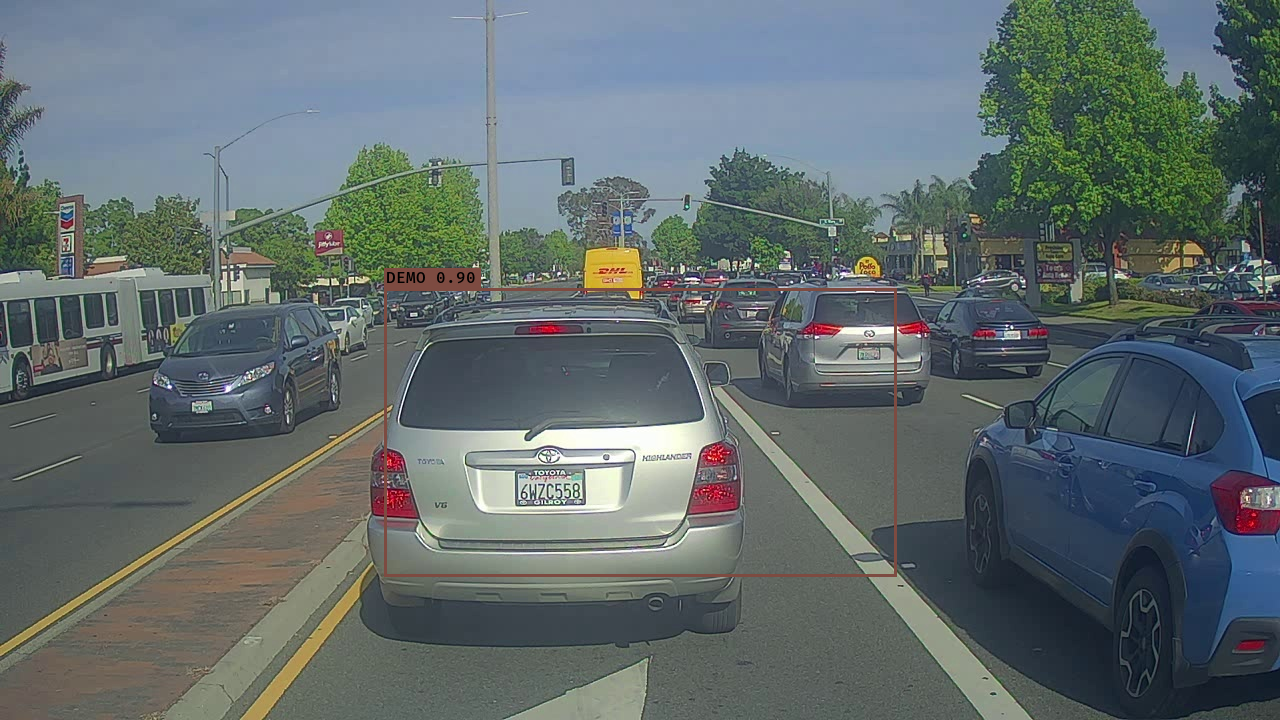

PIL 绘图与 PNG 编码完成。
真实图片检测已跳过：缺少权重或测试图片。


In [11]:
def draw_boxes(image,scores,boxes,classes,names):
    result=image.convert("RGB").copy()
    draw=ImageDraw.Draw(result)
    font_paths=list((ASSIGNMENT_DIR/"font").glob("*.otf"))+list((ASSIGNMENT_DIR/"font").glob("*.ttf"))
    font=ImageFont.truetype(str(font_paths[0]),16) if font_paths else ImageFont.load_default()
    w,h=result.size
    for score,box,cls in zip(scores.detach().cpu().tolist(),boxes.detach().cpu().tolist(),classes.detach().cpu().tolist()):
        y1,x1,y2,x2=box
        x1,x2=max(0,min(w-1,x1)),max(0,min(w-1,x2))
        y1,y2=max(0,min(h-1,y1)),max(0,min(h-1,y2))
        if x2<=x1 or y2<=y1:continue
        color=((37*cls+70)%200+55,(71*cls+20)%200+55,(97*cls+10)%200+55)
        draw.rectangle((x1,y1,x2,y2),outline=color,width=3)
        label=f"{names[cls]} {score:.2f}"
        bounds=draw.textbbox((0,0),label,font=font)
        ty=max(0,y1-(bounds[3]-bounds[1])-8)
        draw.rectangle((x1,ty,min(w-1,x1+bounds[2]+6),y1),fill=color)
        draw.text((x1+2,ty),label,font=font,fill="black")
    return result

TEST_IMAGE=ASSIGNMENT_DIR/"images/test.jpg"
if not TEST_IMAGE.is_file():
    TEST_IMAGE=next(iter(sorted((ASSIGNMENT_DIR/"images").glob("*.jpg"))),None)
if TEST_IMAGE is not None:
    with Image.open(TEST_IMAGE) as source:
        demo_image=source.convert("RGB")
else:
    demo_image=Image.new("RGB",(640,360),"white")
w,h=demo_image.size
print("绘图自检：下图为人工指定的示意框，不是模型预测。",flush=True)
example=draw_boxes(demo_image,torch.tensor([0.9]),
                   torch.tensor([[h*0.4,w*0.3,h*0.8,w*0.7]]),torch.tensor([0]),["DEMO"])
show_image(example)
print("PIL 绘图与 PNG 编码完成。",flush=True)

def predict(image_file,score_threshold=0.6,iou_threshold=0.5,max_boxes=10,class_aware=False):
    if not PRETRAINED_READY:
        raise RuntimeError("请先加载完整且兼容的 YOLOv2 预训练权重。")
    path=Path(image_file)
    if not path.is_absolute():path=ASSIGNMENT_DIR/"images"/path
    started=time.perf_counter()
    with Image.open(path) as source:
        image=source.convert("RGB")
    resized=image.resize((608,608),Image.Resampling.BICUBIC)
    x=torch.from_numpy(np.array(resized)).permute(2,0,1).float().unsqueeze(0).to(device)/255
    print("① 开始前向推理",flush=True)
    yolo_model.eval()
    with torch.no_grad():
        raw=yolo_model(x)
        decoded=yolo_head(raw,anchors,len(class_names))
        print("② 开始筛选与 NMS",flush=True)
        scores,boxes,classes=yolo_eval(tuple(v[0] for v in decoded),(image.height,image.width),
                                       max_boxes,score_threshold,iou_threshold,class_aware)
    print(f"③ 找到 {len(scores)} 个框，用时 {time.perf_counter()-started:.2f}s，开始绘图",flush=True)
    show_image(draw_boxes(image,scores,boxes,classes,class_names))
    print("④ 图片显示调用完成",flush=True)
    return scores,boxes,classes

if PRETRAINED_READY and TEST_IMAGE is not None:
    out_scores,out_boxes,out_classes=predict(TEST_IMAGE)
else:
    print("真实图片检测已跳过：缺少权重或测试图片。",flush=True)

原版展示过“找到 7 个框”的结果，这依赖具体权重、图片、阈值和 NMS，不能作为所有版本必须达到的固定输出。更换自己的图片时，指定绝对路径即可。

In [12]:
MY_IMAGE=None  # 例如 r"C:\Users\21467\Desktop\road.jpg"
if MY_IMAGE is not None and PRETRAINED_READY:
    my_scores,my_boxes,my_classes=predict(MY_IMAGE)

## 4 - YOLO 总结

输入 608×608 → CNN 输出 19×19×5×85 → 解码中心与宽高 → 计算类别分数 → 阈值筛选 → NMS → 显示框。

- 一个 Anchor 有 85 个数，5 个 Anchor 合计每网格 425 个数。
- 分数阈值与 IoU 阈值控制不同步骤；IoU 不是类别概率。
- 框格式、行列/宽高顺序、预处理和权重版本必须一致。
- 本文件保留课程 YOLOv2，不用别的检测器替换四个练习。
- 当前缺失权重不会影响练习与 PIL 绘图；真实检测必须补齐模型参数。

## 5 - 参考资料与数据来源

本文件改编自同目录两份汽车检测 notebook，网络结构对照本地 YAD2K 的 `keras_darknet19.py` 与 `keras_yolo.py`。

原作业参考：Redmon 等的 YOLO（2015）、Redmon 与 Farhadi 的 YOLO9000（2016），以及 Allan Zelener 的 YAD2K。道路样例由 Drive.ai 提供，使用须遵循目录中的 `Drive.ai Dataset Sample LICENSE`；原作者与数据许可证保留在原目录。